In [7]:
import numpy as np
import scipy
from scipy.spatial.transform import Rotation as R
import json
import matplotlib.pyplot as plt
from spatialmath import SE3
import cv2

In [21]:
data = json.load(open("/home/hfiengineering/Documents/sxj749/ros2_ws/handeye_samples.json", "r"))

In [37]:
robot_T_tool = []
cam_T_tag = []

for sample in data['samples']:
    robot_T_tool.append(np.array(sample['base_T_tool']).reshape(4, 4))
    cam_T_tag.append(np.array(sample['cam_T_tag']).reshape(4, 4))

tool_T_tag = SE3().Tz(0.06) @ SE3().Rz(90, unit='deg') @ SE3.Ry(-90, unit='deg')
robot_T_tag = np.array(robot_T_tool) @ tool_T_tag.A
cam_T_tag = np.array(cam_T_tag)

In [48]:
tool_T_tag

   0        -1         0         0         
   0         0        -1         0         
   1         0         0         0.06      
   0         0         0         1         


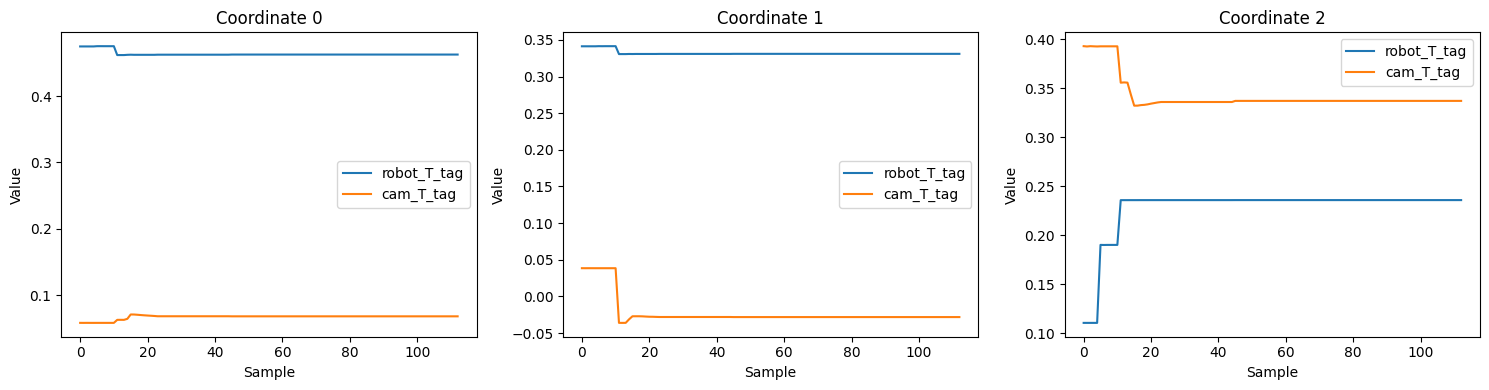

In [34]:
t1 = robot_T_tag[:, :3, 3]
t2 = cam_T_tag[:, :3, 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(t1[:, i], label='robot_T_tag')
    axes[i].plot(t2[:, i], label='cam_T_tag')
    axes[i].set_title(f'Coordinate {i}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('Sample')
    axes[i].legend()

plt.tight_layout()
plt.show()

Min cam_T_robot \in SE3 s.t. cam_T_robot @ robot_tag = camera_T_tag

In [44]:
def inv_tf(T):
    Rm = T[:3, :3]
    t = T[:3, 3]
    Tinv = np.eye(4)
    Tinv[:3, :3] = Rm.T
    Tinv[:3, 3] = -Rm.T @ t
    return Tinv

# robot_T_tool stores base_T_tool, but calibrateHandEye expects gripper2base.
# Invert each transform individually.
gripper2base = [inv_tf(T) for T in robot_T_tool]

R_gripper2base = [T[:3, :3] for T in gripper2base]
t_gripper2base = [T[:3, 3] for T in gripper2base]
R_target2cam = [T[:3, :3] for T in cam_T_tag]
t_target2cam = [T[:3, 3] for T in cam_T_tag]

R_cam_robot, t_cam_robot = cv2.calibrateHandEye(
    R_gripper2base,
    t_gripper2base,
    R_target2cam,
    t_target2cam,
    method=cv2.CALIB_HAND_EYE_PARK,
)


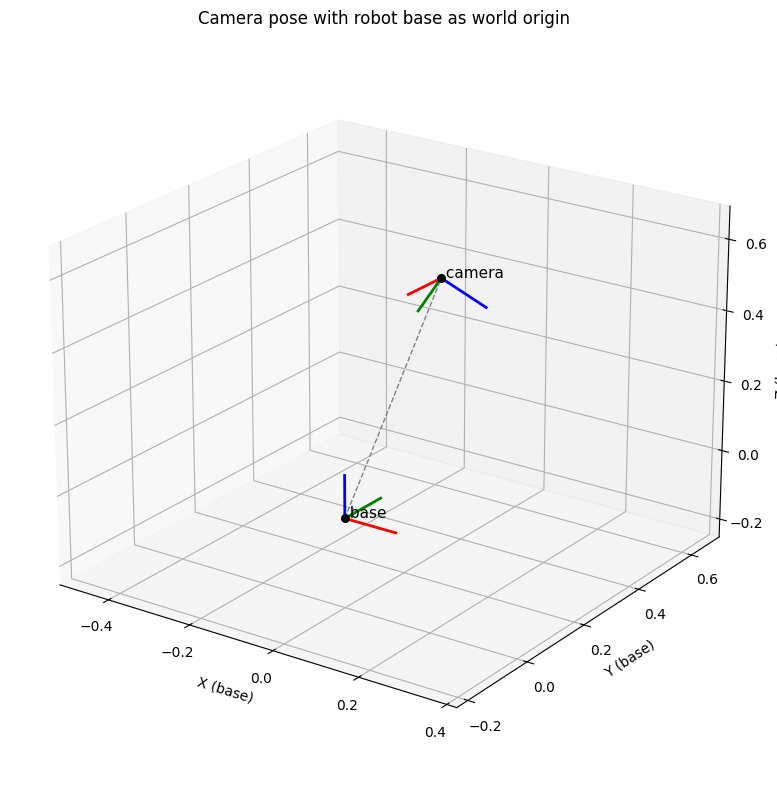

In [45]:
def draw_frame(ax, T, label, scale=0.08):
    origin = T[:3, 3]
    Rm = T[:3, :3]
    colors = ['r', 'g', 'b']
    for axis, color in enumerate(colors):
        end = origin + Rm[:, axis] * scale
        ax.plot([origin[0], end[0]], [origin[1], end[1]], [origin[2], end[2]], color=color, linewidth=2)
    ax.text(origin[0], origin[1], origin[2], f' {label}', fontsize=11)

result = json.load(open('/home/hfiengineering/Documents/sxj749/ros2_ws/src/onr_handeye/onr_handeye/base_T_cam_result.json', 'r'))
base_T_cam = np.array(result['base_T_cam_matrix'], dtype=float)
base_T_base = np.eye(4)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

draw_frame(ax, base_T_base, 'base', scale=0.12)
draw_frame(ax, base_T_cam, 'camera', scale=0.12)

cam_center = base_T_cam[:3, 3]
ax.scatter([0.0], [0.0], [0.0], c='k', s=30)
ax.scatter([cam_center[0]], [cam_center[1]], [cam_center[2]], c='k', s=30)
ax.plot([0.0, cam_center[0]], [0.0, cam_center[1]], [0.0, cam_center[2]], '--', c='gray', linewidth=1)

points = np.vstack([base_T_base[:3, 3], cam_center])
span = np.max(np.ptp(points, axis=0))
span = max(span, 0.2)
center = points.mean(axis=0)
for setter, value in ((ax.set_xlim, center[0]), (ax.set_ylim, center[1]), (ax.set_zlim, center[2])):
    setter(value - span, value + span)

ax.set_xlabel('X (base)')
ax.set_ylabel('Y (base)')
ax.set_zlabel('Z (base)')
ax.set_title('Camera pose with robot base as world origin')
ax.view_init(elev=22, azim=-55)
plt.tight_layout()
plt.show()

In [39]:
# Compute optimal cam_T_robot by averaging per-sample transforms
def inv_tf(T):
    Rmat = T[:3, :3]
    t = T[:3, 3]
    Tinv = np.eye(4)
    Tinv[:3, :3] = Rmat.T
    Tinv[:3, 3] = -Rmat.T @ t
    return Tinv

X_samples = []
for Ai, Bi in zip(robot_T_tag, cam_T_tag):
    X = Bi @ inv_tf(Ai)
    X_samples.append(X)
X_samples = np.array(X_samples)

# Average rotations via quaternion Markley method and translations by mean
from scipy.spatial.transform import Rotation as R
Rs = X_samples[:, :3, :3]
ts = X_samples[:, :3, 3]

quats = R.from_matrix(Rs).as_quat()  # returns [x,y,z,w]
# convert to [w,x,y,z] for Markley average
quats_w = np.column_stack([quats[:, 3], quats[:, 0], quats[:, 1], quats[:, 2]])
M = np.zeros((4, 4))
for q in quats_w:
    M += np.outer(q, q)
eigvals, eigvecs = np.linalg.eig(M)
q_avg = eigvecs[:, np.argmax(eigvals)].real
q_avg /= np.linalg.norm(q_avg)
# back to [x,y,z,w]
q_avg_xyzw = np.array([q_avg[1], q_avg[2], q_avg[3], q_avg[0]])
R_avg = R.from_quat(q_avg_xyzw).as_matrix()
t_avg = ts.mean(axis=0)

cam_T_robot = np.eye(4)
cam_T_robot[:3, :3] = R_avg
cam_T_robot[:3, 3] = t_avg

# Compute per-sample rotation (deg) and translation errors
rot_errs_deg = []
trans_errs = []
for Ai, Bi in zip(robot_T_tag, cam_T_tag):
    pred = cam_T_robot @ Ai
    R_pred = pred[:3, :3]
    R_true = Bi[:3, :3]
    # angle between R_pred and R_true: use R_diff = R_pred.T @ R_true
    R_diff = R_pred.T @ R_true
    rotvec = R.from_matrix(R_diff).as_rotvec()
    angle_deg = np.degrees(np.linalg.norm(rotvec))
    rot_errs_deg.append(angle_deg)
    t_pred = pred[:3, 3]
    t_true = Bi[:3, 3]
    trans_errs.append(np.linalg.norm(t_pred - t_true))

rot_errs_deg = np.array(rot_errs_deg)
trans_errs = np.array(trans_errs)

print('cam_T_robot:')
np.set_printoptions(suppress=True, precision=6)
print(cam_T_robot)
print()
print(f'Rotation error (deg): mean={rot_errs_deg.mean():.4f}, std={rot_errs_deg.std():.4f}')
print(f'Translation error: mean={trans_errs.mean():.6f}, std={trans_errs.std():.6f}')

np.save("cam_T_robot.npy", cam_T_robot)

cam_T_robot:
[[-0.019098 -0.999633 -0.01919   0.460114]
 [-0.44271   0.025664 -0.896298  0.364204]
 [ 0.896462 -0.008622 -0.443037  0.054552]
 [ 0.        0.        0.        1.      ]]

Rotation error (deg): mean=3.7295, std=7.7691
Translation error: mean=0.010636, std=0.017090


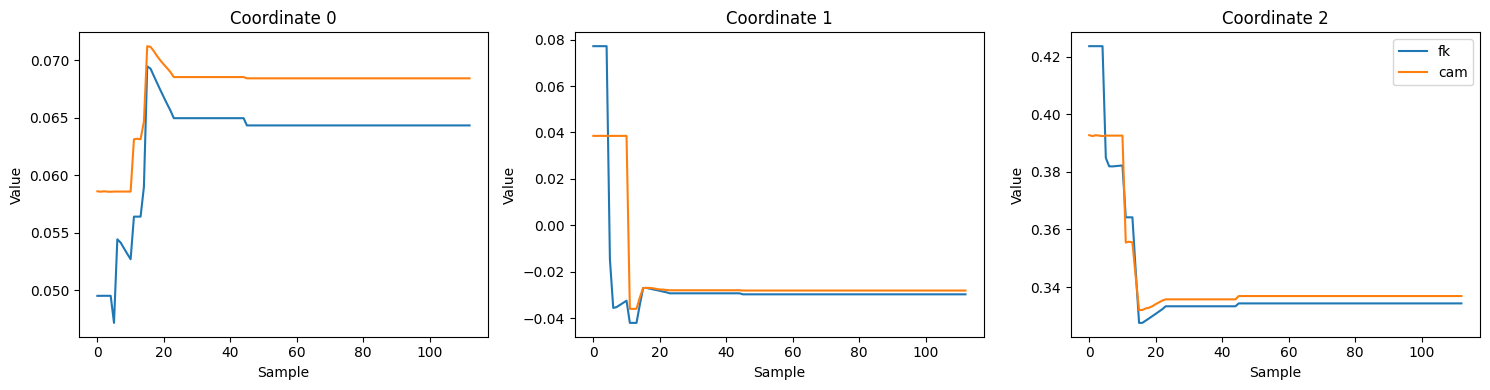

In [30]:
t1 = (cam_T_robot @ robot_T_tag)[:, :3, 3]
t2 = cam_T_tag[:, :3, 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(t1[:, i], label='fk')
    axes[i].plot(t2[:, i], label='cam')
    axes[i].set_title(f'Coordinate {i}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('Sample')
axes[-1].legend()

plt.tight_layout()
plt.show()

In [3]:
arr= np.load("cam_T_robot.npy")
print(arr)

[[-0.01909843 -0.99963343 -0.01919005  0.46011403]
 [-0.44270951  0.02566447 -0.89629773  0.36420377]
 [ 0.89646168 -0.00862226 -0.44303738  0.05455157]
 [ 0.          0.          0.          1.        ]]
